In [3]:
import pandas as pd
import networkx as nx
import numpy as np
from pathlib import Path
from node2vec import Node2Vec
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
data_dir = Path("./")

df_friend = pd.read_csv(data_dir / "friend_with.csv")

print("Shape:", df_friend.shape)
print("Columns:", df_friend.columns.tolist())
display(df_friend.head(10))

Shape: (10442, 3)
Columns: ['startUserId', 'endUserId', 'since']


,startUserId,endUserId,since
0,U0001,U0129,2025-05-03T01:10:55
1,U0129,U0001,2025-05-03T01:10:55
2,U0001,U0748,2026-01-16T22:01:53
3,U0748,U0001,2026-01-16T22:01:53
4,U0001,U0673,2025-09-05T14:45:18
5,U0673,U0001,2025-09-05T14:45:18
6,U0001,U0276,2026-03-16T17:37:21
7,U0276,U0001,2026-03-16T17:37:21
8,U0001,U0409,2025-07-03T03:47:54
9,U0409,U0001,2025-07-03T03:47:54


In [5]:
SOURCE_COL = "startUserId"
TARGET_COL = "endUserId"

In [6]:
df_edges = df_friend[[SOURCE_COL, TARGET_COL]].copy()

# bỏ null
df_edges = df_edges.dropna()

# bỏ self-loop
df_edges = df_edges[df_edges[SOURCE_COL] != df_edges[TARGET_COL]]

# chuẩn hóa cạnh vô hướng: (A,B) và (B,A) thành 1
df_edges["user_min"] = df_edges[[SOURCE_COL, TARGET_COL]].min(axis=1)
df_edges["user_max"] = df_edges[[SOURCE_COL, TARGET_COL]].max(axis=1)

df_edges = df_edges[["user_min", "user_max"]].drop_duplicates()
df_edges.columns = ["source", "target"]

print("Số cạnh sau làm sạch:", len(df_edges))
display(df_edges.head(10))

Số cạnh sau làm sạch: 5221


,source,target
0,U0001,U0129
2,U0001,U0748
4,U0001,U0673
6,U0001,U0276
8,U0001,U0409
10,U0001,U0296
12,U0001,U0544
14,U0002,U0085
16,U0002,U0523
18,U0002,U0181


In [7]:
G = nx.from_pandas_edgelist(
    df_edges,
    source="source",
    target="target",
    create_using=nx.Graph()
)

print("Số node:", G.number_of_nodes())
print("Số edge:", G.number_of_edges())

Số node: 900
Số edge: 5221


In [8]:
from node2vec import Node2Vec
import os

node2vec = Node2Vec(
    G,
    dimensions=128,     # tăng độ giàu thông tin embedding
    walk_length=30,     # mỗi walk dài hơn
    num_walks=50,      # từ 50 -> 200 (nặng hơn rõ rệt)
    workers=4,
    p=1,
    q=2,
    seed=42
)

model = node2vec.fit(
    window=10,
    min_count=1,
    batch_words=128,
    epochs=10           # tăng số epoch Word2Vec
)

print("Train xong Node2Vec")


Computing transition probabilities:   0%|          | 0/900 [00:00<?, ?it/s]

Train xong Node2Vec


In [9]:
# KMeans trên embedding Node2Vec

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# embeddings: đã có từ notebook của bạn
# nodes: list user_id tương ứng từng dòng embedding

# 1) Chọn số cụm K tự động (thử từ 6..11)
k_range = range(6, 12)
best_k = None
best_score = -1

for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_tmp = km_tmp.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels_tmp)
    print(f"k={k}, silhouette={score:.4f}")
    if score > best_score:
        best_score = score
        best_k = k

print(f"\nBest k = {best_k}, best silhouette = {best_score:.4f}")

# 2) Train KMeans với K tốt nhất
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(embeddings)

# 3) Gán cụm cho user
df_cluster = pd.DataFrame({
    "user_id": nodes,
    "cluster": cluster_labels
})

display(df_cluster.head(20))



NameError: name 'embeddings' is not defined

c:\Users\Thinh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


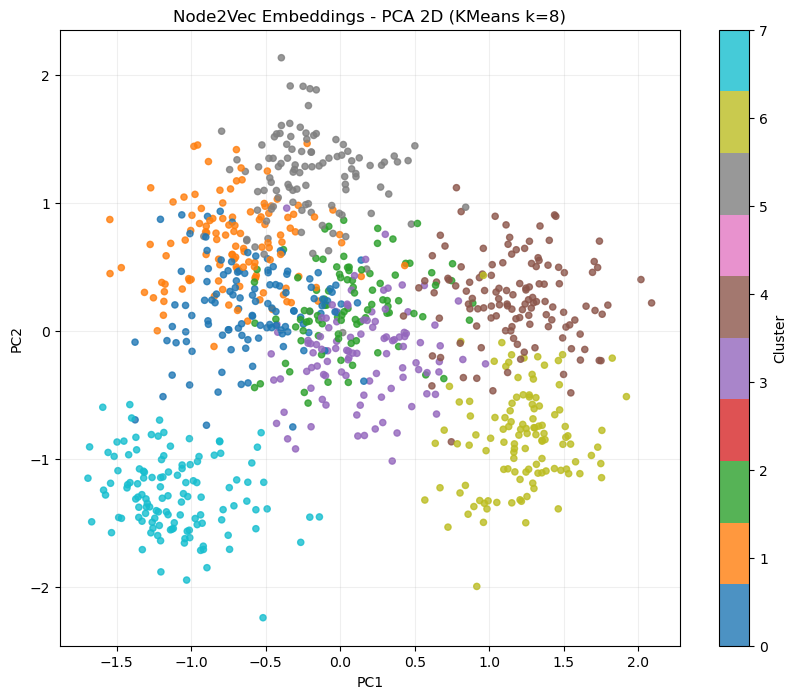

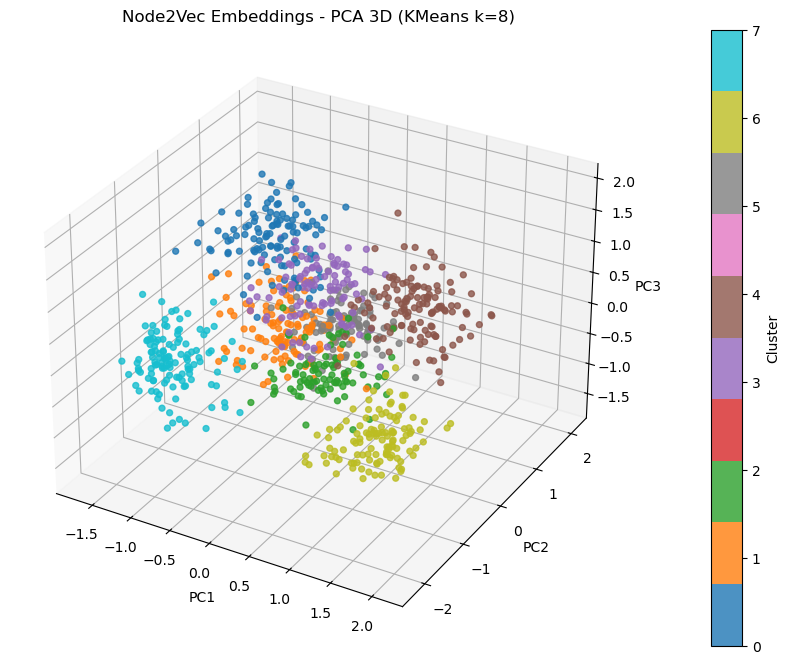

Đã lưu user_pca_clustered.csv


In [ ]:
# PCA 2D + 3D tô màu theo cụm KMeans

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import pandas as pd
import numpy as np

# embeddings: np.array (n_users, dim)
# nodes: list user_id theo thứ tự embeddings

# 1) KMeans (chỉnh k tùy bạn)
k = 8
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(embeddings)

# 2) PCA 2D
pca2 = PCA(n_components=2, random_state=42)
X2 = pca2.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
sc2 = plt.scatter(
    X2[:, 0], X2[:, 1],
    c=cluster_labels,
    cmap="tab10",
    s=20,
    alpha=0.8
)
plt.title(f"Node2Vec Embeddings - PCA 2D (KMeans k={k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
cbar = plt.colorbar(sc2)
cbar.set_label("Cluster")
plt.show()

# 3) PCA 3D
pca3 = PCA(n_components=3, random_state=42)
X3 = pca3.fit_transform(embeddings)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
sc3 = ax.scatter(
    X3[:, 0], X3[:, 1], X3[:, 2],
    c=cluster_labels,
    cmap="tab10",
    s=18,
    alpha=0.8
)
ax.set_title(f"Node2Vec Embeddings - PCA 3D (KMeans k={k})")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
fig.colorbar(sc3, ax=ax, pad=0.1, label="Cluster")
plt.show()

# 4) Lưu file kết quả
df_vis = pd.DataFrame({
    "user_id": nodes,
    "cluster": cluster_labels,
    "pc1_2d": X2[:, 0],
    "pc2_2d": X2[:, 1],
    "pc1_3d": X3[:, 0],
    "pc2_3d": X3[:, 1],
    "pc3_3d": X3[:, 2],
})
df_vis.to_csv("user_pca_clustered.csv", index=False, encoding="utf-8-sig")
print("Đã lưu user_pca_clustered.csv")


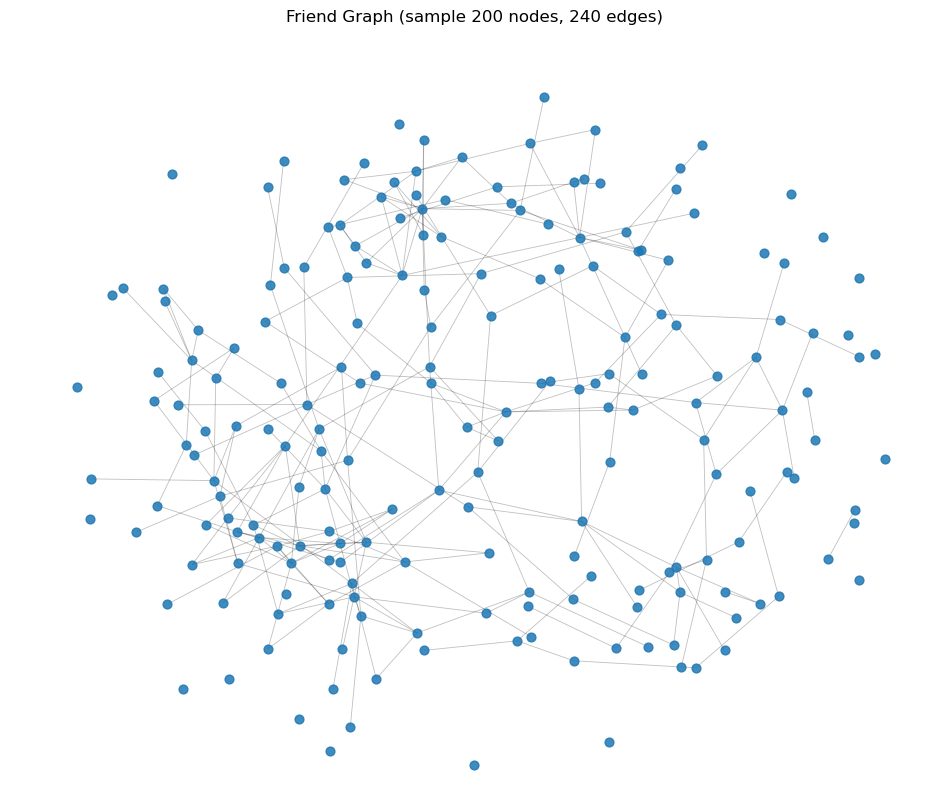

In [ ]:
# Vẽ graph bạn bè từ G (NetworkX)

import matplotlib.pyplot as plt
import networkx as nx
import random

# 1) Nếu graph lớn, lấy sample để nhìn rõ hơn
sample_size = 200  # đổi lên 400/900 nếu máy chịu được
all_nodes = list(G.nodes())
sample_nodes = random.sample(all_nodes, min(sample_size, len(all_nodes)))
SG = G.subgraph(sample_nodes).copy()

# 2) Layout + vẽ
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(SG, seed=42, k=0.25)

nx.draw_networkx_nodes(SG, pos, node_size=40, alpha=0.85)
nx.draw_networkx_edges(SG, pos, alpha=0.25, width=0.6)

plt.title(f"Friend Graph (sample {SG.number_of_nodes()} nodes, {SG.number_of_edges()} edges)")
plt.axis("off")
plt.show()


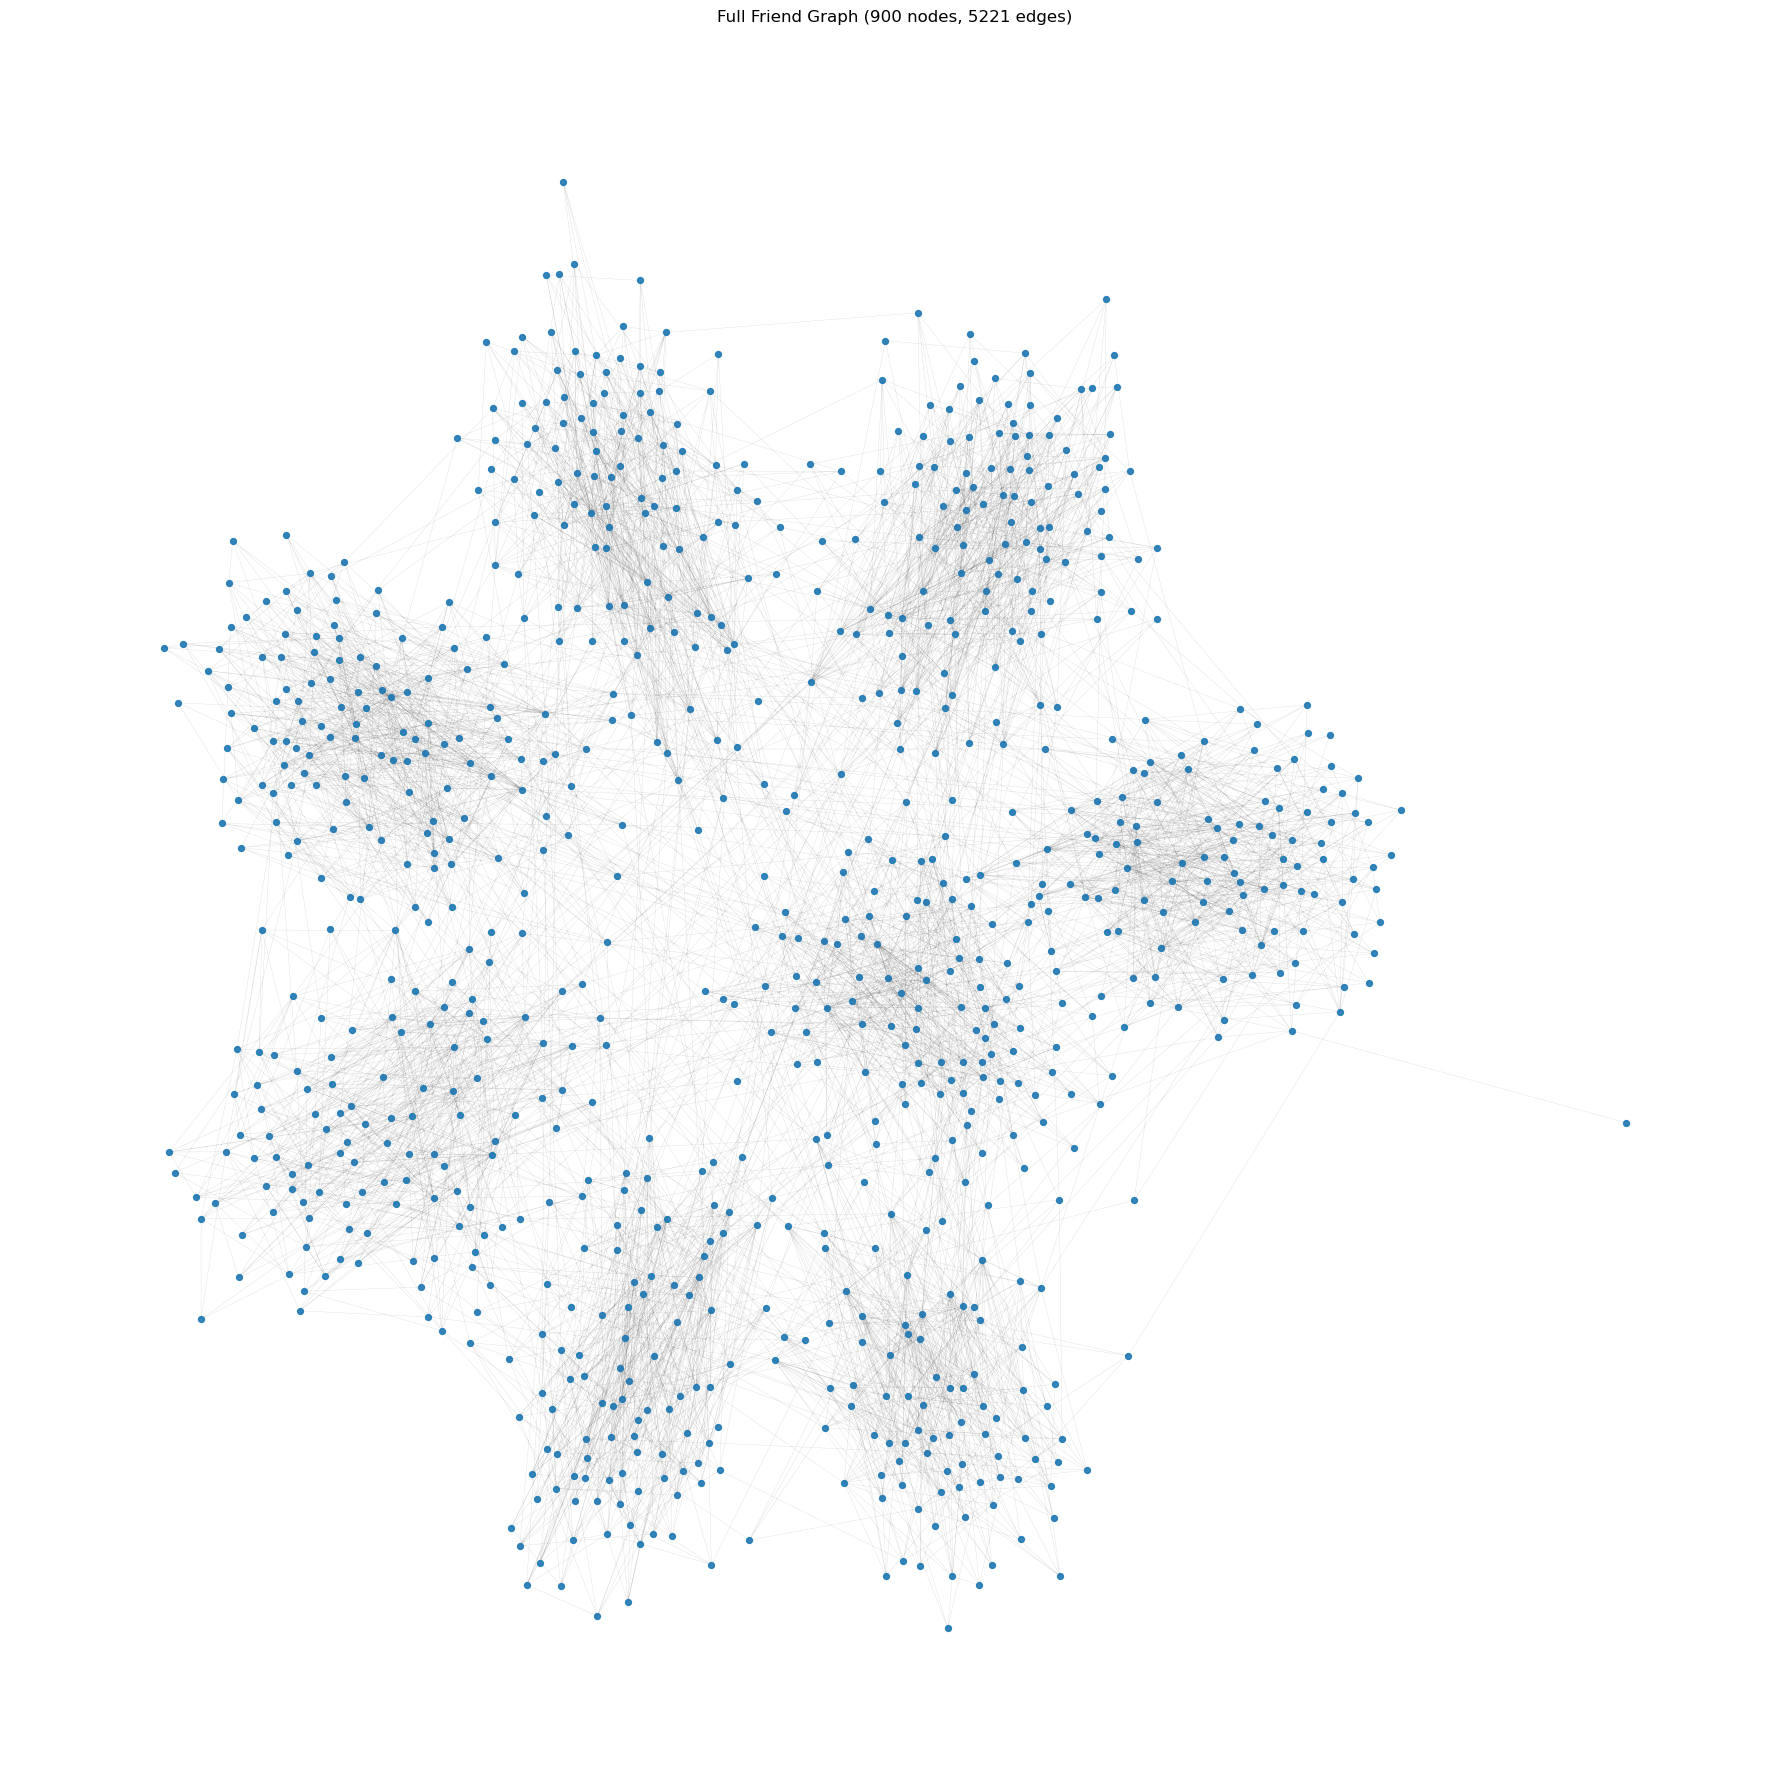

In [ ]:
# Vẽ FULL graph (toàn bộ node + edge trong G)

import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(18, 18))

# full graph
SG = G

# K nhỏ hơn để cụm đỡ dính nhau
pos = nx.spring_layout(SG, seed=42, k=0.12, iterations=200)

nx.draw_networkx_nodes(
    SG, pos,
    node_size=18,
    alpha=0.9
)
nx.draw_networkx_edges(
    SG, pos,
    width=0.25,
    alpha=0.15
)

plt.title(f"Full Friend Graph ({SG.number_of_nodes()} nodes, {SG.number_of_edges()} edges)")
plt.axis("off")
plt.tight_layout()
plt.show()


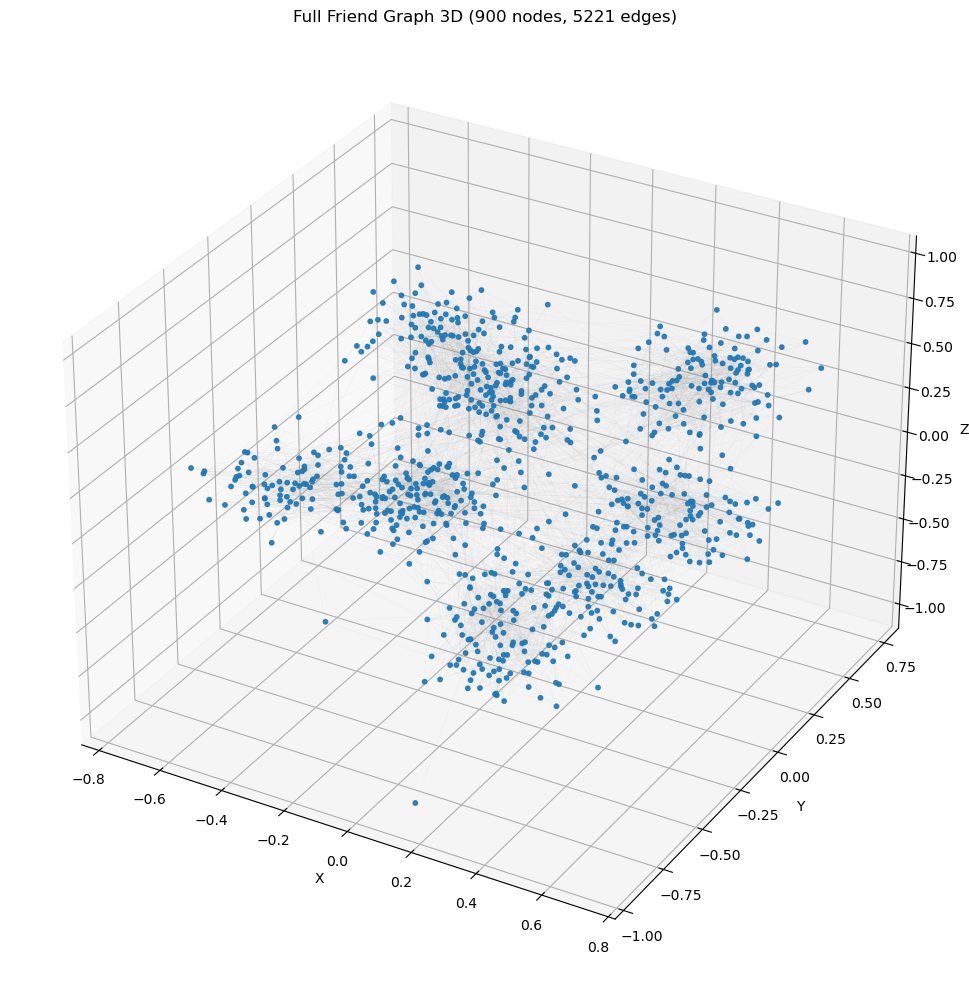

In [ ]:
# Vẽ FULL graph 3D (networkx + matplotlib)

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

SG = G  # full graph

# 3D spring layout
pos_3d = nx.spring_layout(SG, dim=3, seed=42, k=0.12, iterations=120)

# Tách tọa độ node
xyz = np.array([pos_3d[v] for v in SG.nodes()])
x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

# Vẽ edges
for u, v in SG.edges():
    xline = [pos_3d[u][0], pos_3d[v][0]]
    yline = [pos_3d[u][1], pos_3d[v][1]]
    zline = [pos_3d[u][2], pos_3d[v][2]]
    ax.plot(xline, yline, zline, color="gray", alpha=0.08, linewidth=0.3)

# Vẽ nodes
ax.scatter(x, y, z, s=10, alpha=0.9)

ax.set_title(f"Full Friend Graph 3D ({SG.number_of_nodes()} nodes, {SG.number_of_edges()} edges)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.tight_layout()
plt.show()


In [2]:
# 3D graph có màu theo cụm + xoay trực tiếp trong notebook (matplotlib)

# Nếu đang dùng Jupyter:
# chạy 1 trong 2 dòng dưới để bật tương tác xoay
# %matplotlib widget
%matplotlib notebook

import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
import numpy as np
from sklearn.cluster import KMeans

SG = G  # full graph

# 1) Gán cụm để tô màu node
k = 8
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(embeddings)

node_order = list(SG.nodes())  # phải cùng thứ tự để map màu
node_to_idx = {n: i for i, n in enumerate(nodes)}  # nodes là list dùng tạo embeddings
node_clusters = np.array([cluster_labels[node_to_idx[n]] for n in node_order])

# 2) Layout 3D
pos_3d = nx.spring_layout(SG, dim=3, seed=42, k=0.12, iterations=100)

xyz = np.array([pos_3d[n] for n in node_order])
x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]

# 3) Vẽ
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection="3d")

# edges
for u, v in SG.edges():
    ax.plot(
        [pos_3d[u][0], pos_3d[v][0]],
        [pos_3d[u][1], pos_3d[v][1]],
        [pos_3d[u][2], pos_3d[v][2]],
        color="gray", alpha=0.06, linewidth=0.3
    )

# nodes có màu cụm
sc = ax.scatter(
    x, y, z,
    c=node_clusters,
    cmap="tab10",
    s=10,
    alpha=0.9
)

ax.set_title(f"Full Friend Graph 3D - Colored by KMeans (k={k})")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

cbar = fig.colorbar(sc, ax=ax, pad=0.08)
cbar.set_label("Cluster")

# góc nhìn ban đầu
ax.view_init(elev=20, azim=40)

plt.tight_layout()
plt.show()


NameError: name 'G' is not defined